In [19]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [20]:
!pip install yfinance --upgrade --quiet

In [21]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

In [22]:
tesla = yf.Ticker("TSLA")

In [23]:
tesla_history = tesla.history(period="max")
tesla_history.reset_index(inplace=True)

In [24]:
tesla_history.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2010-06-29 00:00:00-04:00,1.266667,1.666667,1.169333,1.592667,281494500,0.0,0.0
1,2010-06-30 00:00:00-04:00,1.719333,2.028000,1.553333,1.588667,257806500,0.0,0.0
2,2010-07-01 00:00:00-04:00,1.666667,1.728000,1.351333,1.464000,123282000,0.0,0.0
3,2010-07-02 00:00:00-04:00,1.533333,1.540000,1.247333,1.280000,77097000,0.0,0.0
4,2010-07-06 00:00:00-04:00,1.333333,1.333333,1.055333,1.074000,103003500,0.0,0.0


### Load html to have Tesla Revenue

In [25]:
import requests
from bs4 import BeautifulSoup
import re

In [26]:
url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-PY0220EN-SkillsNetwork/labs/project/revenue.htm'

headers = {
    "User-Agent": "Mozilla/5.0",
    "Accept-Language": "en-US,en;q=0.9"
}

response = requests.get(url, headers=headers)

soup = BeautifulSoup(response.text, "html.parser")

In [27]:
def to_float_or_zero(value):
    try:
        return float(value)
    except (ValueError, TypeError):
        return 0

In [16]:
tag_quaterly_revenue = soup.find(string=re.compile("Tesla Quarterly Revenue"))
table_body = tag_quaterly_revenue.find_next("tbody")

list_date = []
list_revenue = []

for tr in table_body.find_all("tr"):
    date_text = tr.contents[1].get_text()
    revenue_text= tr.contents[3].get_text().replace("$","").replace(",","")
    
    list_date.append(pd.to_datetime(date_text, format='%Y-%m-%d'))
    list_revenue.append(to_float_or_zero(revenue_text))

In [28]:
df_tesla_revenue = pd.DataFrame({
    'Date': list_date,
    'Revenue': list_revenue
})
df_tesla_revenue.tail()

,Date,Revenue
49,2010-06-30,28.0
50,2010-03-31,21.0
51,2009-12-31,0.0
52,2009-09-30,46.0
53,2009-06-30,27.0


### Load stock values for GameStop 

In [29]:
gamestop = yf.Ticker("GME")

In [30]:
gamestop_history = gamestop.history(period="max")
gamestop_history.reset_index(inplace=True)

In [31]:
gamestop_history.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2002-02-13 00:00:00-05:00,1.620129,1.693350,1.603296,1.691667,76216000,0.0,0.0
1,2002-02-14 00:00:00-05:00,1.712707,1.716074,1.670626,1.683250,11021600,0.0,0.0
2,2002-02-15 00:00:00-05:00,1.683250,1.687458,1.658001,1.674834,8389600,0.0,0.0
3,2002-02-19 00:00:00-05:00,1.666418,1.666418,1.578048,1.607504,7410400,0.0,0.0
4,2002-02-20 00:00:00-05:00,1.615921,1.662210,1.603296,1.662210,6892800,0.0,0.0


In [32]:
url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-PY0220EN-SkillsNetwork/labs/project/stock.html'

headers = {
    "User-Agent": "Mozilla/5.0",
    "Accept-Language": "en-US,en;q=0.9"
}

response = requests.get(url, headers=headers)

soup = BeautifulSoup(response.text, "html.parser")

In [33]:
tag_quaterly_revenue = soup.find(string=re.compile("GameStop Quarterly Revenue"))
table_body = tag_quaterly_revenue.find_next("tbody")

list_date = []
list_revenue = []

for tr in table_body.find_all("tr"):
    date_text = tr.contents[1].get_text()
    revenue_text= tr.contents[3].get_text().replace("$","").replace(",","")
    
    list_date.append(pd.to_datetime(date_text, format='%Y-%m-%d'))
    list_revenue.append(to_float_or_zero(revenue_text))

### Create a Dataframe to keep dates and revenues for GameStop

In [34]:
df_game_stop_revenue = pd.DataFrame({
    'Date': list_date,
    'Revenue': list_revenue
})
df_game_stop_revenue.tail()

,Date,Revenue
57,2006-01-31,1667.0
58,2005-10-31,534.0
59,2005-07-31,416.0
60,2005-04-30,475.0
61,2005-01-31,709.0


In [35]:
import matplotlib.pyplot as plt

def make_graph(stock_data, revenue_data, stock_name):
    fig, ax1 = plt.subplots(figsize=(14, 6))

    # Eixo para stock
    ax1.plot(stock_data['Date'], stock_data['Close'], 'r-', label='Stock Price')
    ax1.set_xlabel('Date')
    ax1.set_ylabel('Stock Price', color='r')
    ax1.tick_params(axis='y', labelcolor='r')

    # Eixo para revenue (do lado direito)
    ax2 = ax1.twinx()
    ax2.plot(revenue_data['Date'], revenue_data['Revenue'], 'b-', label='Revenue')
    ax2.set_ylabel('Revenue', color='b')
    ax2.tick_params(axis='y', labelcolor='b')

    # Título e layout
    plt.title(f"{stock_name} Stock Price and Revenue")
    fig.tight_layout()
    plt.show()

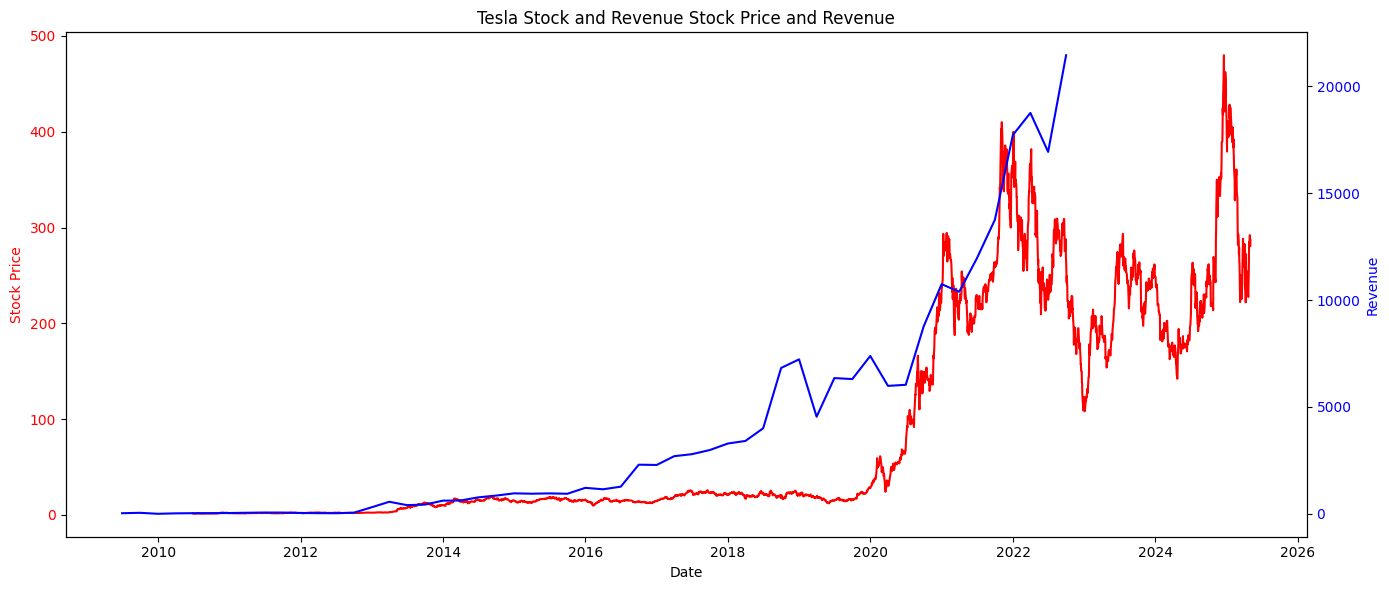

In [37]:
make_graph(tesla_history, df_tesla_revenue, stock_name='Tesla Stock and Revenue')

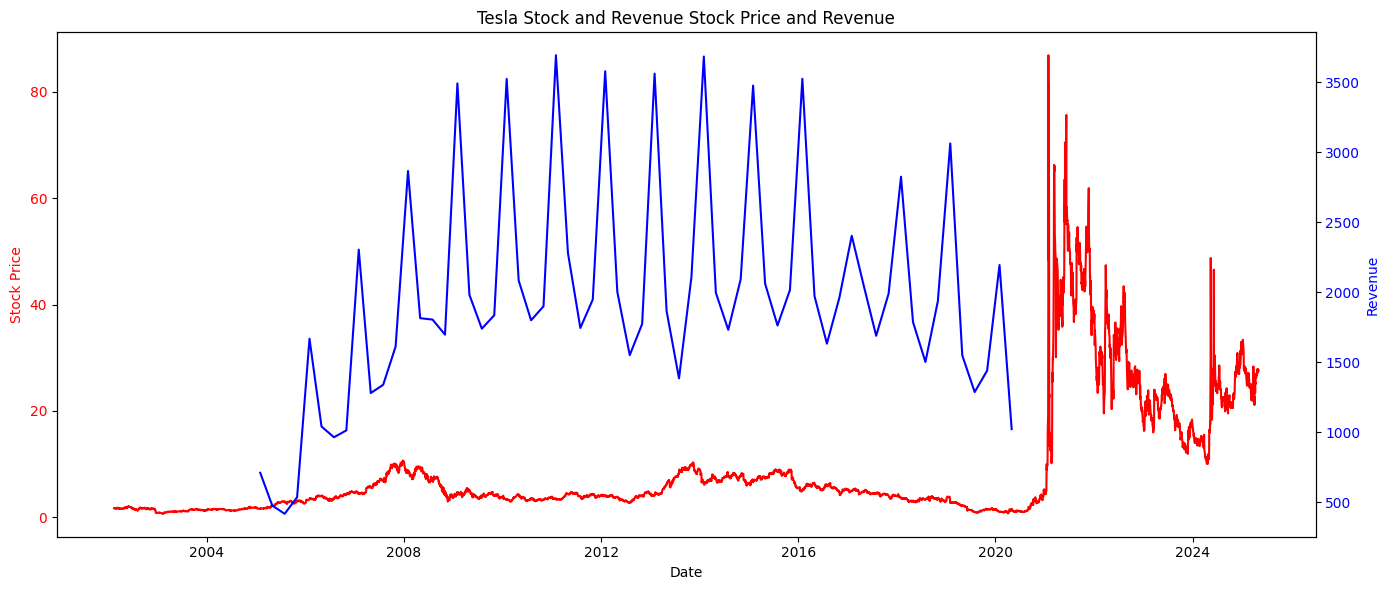

In [38]:
make_graph(gamestop_history, df_game_stop_revenue, stock_name='Tesla Stock and Revenue')